In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

# Implementation of AND, OR, NOT, XOR gate using single layer perceptron

In [ ]:
# Define inputs and outputs
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
X_not = np.array([0,1])

y_and = np.array([0,0,0,1])
y_or = np.array([0,1,1,1])
y_not = np.array([1,0])

In [ ]:
# Initialise weights and bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 10

In [ ]:
# Step activation function
def step(z):
    if z >0:
        return 1
    else:
        return 0

In [ ]:
# Plot decision boundary for each update
def plot_all_boundaries(X, y, history, gate_name):

    n = len(history) + 1
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                             figsize=(5*cols, 5*rows))

    axes = np.array(axes).reshape(-1)

    # Initial weights
    history = [{
        "weights": np.zeros(X.shape[1]),
        "bias": 0,
        "title": "Initial"
    }] + history

    for ax, state in zip(axes, history):

        weights = state["weights"]
        bias = state["bias"]

        label0 = False
        label1 = False

        for i in range(len(X)):
            if y[i] == 0:
                ax.scatter(
                    X[i][0], X[i][1],
                    color='red',
                    label='Class 0' if not label0 else ""
                )
                label0 = True
            else:
                ax.scatter(
                    X[i][0], X[i][1],
                    color='blue',
                    label='Class 1' if not label1 else ""
                )
                label1 = True

        x_values = np.array([-0.5, 1.5])

        if weights[1] != 0:
            y_values = -(weights[0]*x_values + bias)/weights[1]
            ax.plot(x_values, y_values,
                    color='green',
                    label='Decision Boundary')

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_xlabel("Input X1")
        ax.set_ylabel("Input X2")
        ax.set_title(state["title"])
        ax.grid(True)

    for ax in axes[len(history):]:
        fig.delaxes(ax)

    handles = []
    labels = []

    for ax in axes[:len(history)]:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(handles, labels, loc="upper right")

    fig.suptitle(f"Training {gate_name} gate using Single Layer Perceptron",
                 fontsize=18,
                 fontweight="bold")

    plt.tight_layout(rect=[0, 0, 0.95, 0.97])
    plt.savefig(f"{gate_name}_Decision_Boundaries.eps",
            format="eps",
            bbox_inches="tight")
    plt.show()

In [ ]:
#  Perceptron training
def Perceptron(X, y, gate_name, learning_rate=0.1, epochs=10):
    history=[]
    weights = np.zeros(X.shape[1])
    bias = 0

    for epoch in range(epochs):

        error = 0

        for i in range(len(X)):

            z = np.dot(X[i], weights) + bias
            y_pred = step(z)

            update = learning_rate * (y[i] - y_pred)

            weights += update * X[i]
            bias += update

            print(f"Epoch {epoch+1}")
            print(f"Input      : {X[i]}")
            print(f"Target     : {y[i]}")
            print(f"Prediction : {y_pred}")
            print(f"Weights    : {weights}")
            print(f"Bias       : {bias}\n")

            if update != 0:
                error += 1
                history.append({
                    "weights": weights.copy(),
                    "bias": bias,
                    "title": f"Update {len(history)+1}"
                })
        if error == 0:
            print("Training Complete")
            break
    plot_all_boundaries(X, y, history, gate_name)

    return weights, bias

Epoch 1
Input      : [0 0]
Target     : 0
Prediction : 0
Weights    : [0. 0.]
Bias       : 0.0

Epoch 1
Input      : [0 1]
Target     : 0
Prediction : 0
Weights    : [0. 0.]
Bias       : 0.0

Epoch 1
Input      : [1 0]
Target     : 0
Prediction : 0
Weights    : [0. 0.]
Bias       : 0.0

Epoch 1
Input      : [1 1]
Target     : 1
Prediction : 0
Weights    : [0.1 0.1]
Bias       : 0.1

Epoch 2
Input      : [0 0]
Target     : 0
Prediction : 1
Weights    : [0.1 0.1]
Bias       : 0.0

Epoch 2
Input      : [0 1]
Target     : 0
Prediction : 1
Weights    : [0.1 0. ]
Bias       : -0.1

Epoch 2
Input      : [1 0]
Target     : 0
Prediction : 0
Weights    : [0.1 0. ]
Bias       : -0.1

Epoch 2
Input      : [1 1]
Target     : 1
Prediction : 0
Weights    : [0.2 0.1]
Bias       : 0.0

Epoch 3
Input      : [0 0]
Target     : 0
Prediction : 0
Weights    : [0.2 0.1]
Bias       : 0.0

Epoch 3
Input      : [0 1]
Target     : 0
Prediction : 1
Weights    : [0.2 0. ]
Bias       : -0.1

Epoch 3
Input      : [1

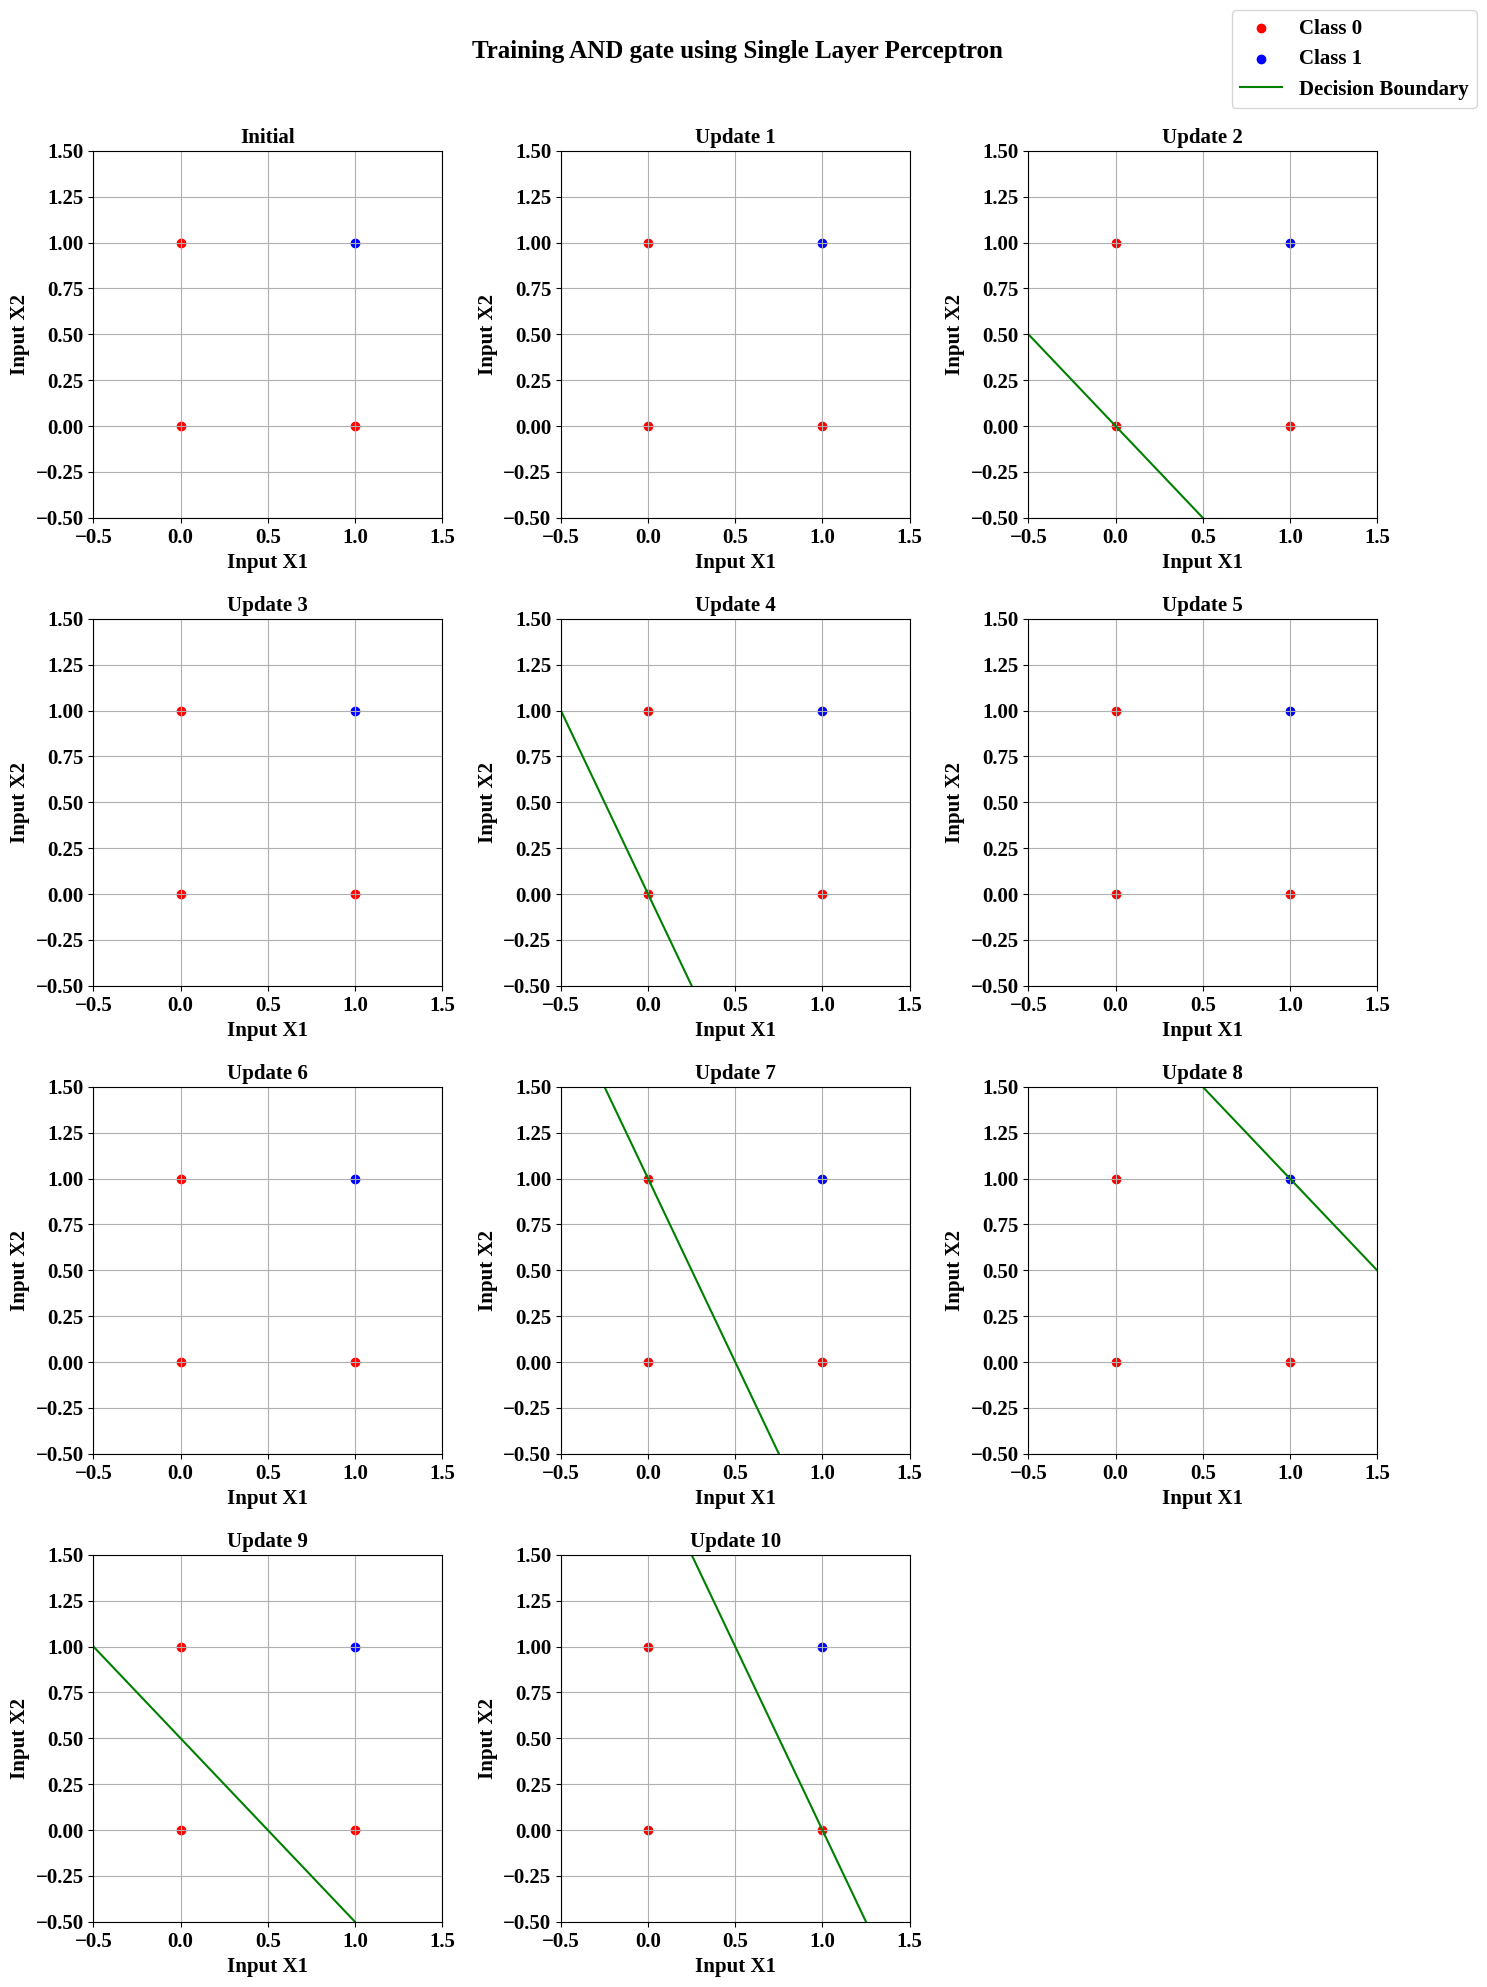

In [ ]:
# Training AND gate
weights_and, bias_and = Perceptron(X, y_and, "AND")

Epoch 1
Input      : [0 0]
Target     : 0
Prediction : 0
Weights    : [0. 0.]
Bias       : 0.0

Epoch 1
Input      : [0 1]
Target     : 1
Prediction : 0
Weights    : [0.  0.1]
Bias       : 0.1

Epoch 1
Input      : [1 0]
Target     : 1
Prediction : 1
Weights    : [0.  0.1]
Bias       : 0.1

Epoch 1
Input      : [1 1]
Target     : 1
Prediction : 1
Weights    : [0.  0.1]
Bias       : 0.1

Epoch 2
Input      : [0 0]
Target     : 0
Prediction : 1
Weights    : [0.  0.1]
Bias       : 0.0

Epoch 2
Input      : [0 1]
Target     : 1
Prediction : 1
Weights    : [0.  0.1]
Bias       : 0.0

Epoch 2
Input      : [1 0]
Target     : 1
Prediction : 0
Weights    : [0.1 0.1]
Bias       : 0.1

Epoch 2
Input      : [1 1]
Target     : 1
Prediction : 1
Weights    : [0.1 0.1]
Bias       : 0.1

Epoch 3
Input      : [0 0]
Target     : 0
Prediction : 1
Weights    : [0.1 0.1]
Bias       : 0.0

Epoch 3
Input      : [0 1]
Target     : 1
Prediction : 1
Weights    : [0.1 0.1]
Bias       : 0.0

Epoch 3
Input      : [

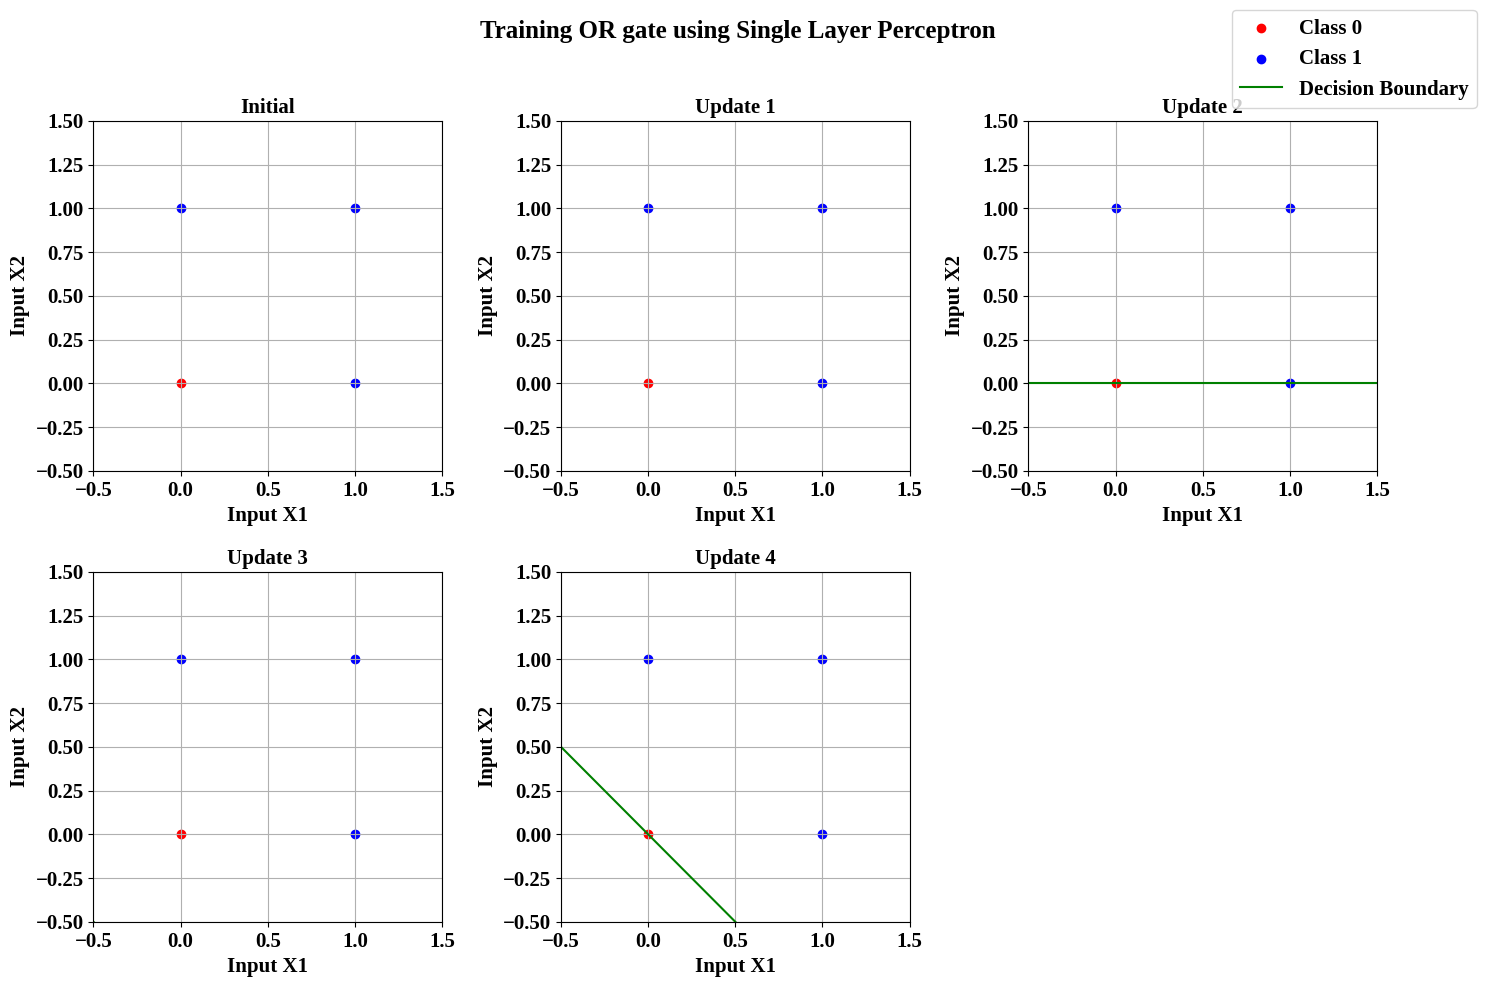

In [ ]:
# Training OR gate
weights_or, bias_or = Perceptron(X, y_or, "OR")

In [ ]:
# Perceptron traingn for NOT gate
def Perceptron_NOT(X, y, learning_rate=0.1, epochs=10):

    weight = 0
    bias = 0

    history = [{
        "weight": weight,
        "bias": bias,
        "title": "Initial"
    }]

    update_no = 0

    for epoch in range(epochs):

        error = 0

        for i in range(len(X)):

            z = X[i] * weight + bias
            y_pred = step(z)

            update = learning_rate * (y[i] - y_pred)

            weight += update * X[i]
            bias += update

            print(f"Epoch {epoch+1}")
            print(f"Input      : {X[i]}")
            print(f"Target     : {y[i]}")
            print(f"Prediction : {y_pred}")
            print(f"Weight     : {weight}")
            print(f"Bias       : {bias}\n")

            if update != 0:

                update_no += 1
                error += 1

                history.append({
                    "weight": weight,
                    "bias": bias,
                    "title": f"Update {update_no}"
                })

        if error == 0:
            print("Training Complete")
            break

    plot_not_updates(X, y, history)

    return weight, bias

In [ ]:
# Plot decision boundary for each update for NOT gate
def plot_not_updates(X, y, history):

    n = len(history)
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                             figsize=(5*cols, 3*rows))

    axes = np.array(axes).reshape(-1)

    for ax, state in zip(axes, history):

        label0 = False
        label1 = False

        for i in range(len(X)):

            if y[i] == 0:
                ax.scatter(X[i], 0,
                           color='red',
                           s=100,
                           label='Class 0' if not label0 else "")
                label0 = True

            else:
                ax.scatter(X[i], 0,
                           color='blue',
                           s=100,
                           label='Class 1' if not label1 else "")
                label1 = True

        if state["weight"] != 0:
            boundary = -state["bias"] / state["weight"]

            ax.axvline(boundary,
                       color='green',
                       linestyle='-',
                       label='Decision Boundary')

        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 0.5)

        ax.set_yticks([])
        ax.set_xlabel("Input")
        ax.set_title(state["title"])
        ax.grid(True)

    for ax in axes[n:]:
        fig.delaxes(ax)

    handles = []
    labels = []

    for ax in axes[:n]:
        h, l = ax.get_legend_handles_labels()

        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(handles, labels,
           loc="upper left",
           bbox_to_anchor=(0.85, 0.98))

    fig.suptitle("Training NOT Gate using Single Layer Perceptron",
                 fontsize=18,
                 fontweight="bold")

    plt.tight_layout(rect=[0, 0, 0.85, 0.95])

    plt.savefig("NOT_Gate_Decision_Boundaries.eps",
                format="eps",
                bbox_inches="tight")

    plt.show()

Epoch 1
Input      : 0
Target     : 1
Prediction : 0
Weight     : 0.0
Bias       : 0.1

Epoch 1
Input      : 1
Target     : 0
Prediction : 1
Weight     : -0.1
Bias       : 0.0

Epoch 2
Input      : 0
Target     : 1
Prediction : 0
Weight     : -0.1
Bias       : 0.1

Epoch 2
Input      : 1
Target     : 0
Prediction : 0
Weight     : -0.1
Bias       : 0.1

Epoch 3
Input      : 0
Target     : 1
Prediction : 1
Weight     : -0.1
Bias       : 0.1

Epoch 3
Input      : 1
Target     : 0
Prediction : 0
Weight     : -0.1
Bias       : 0.1

Training Complete


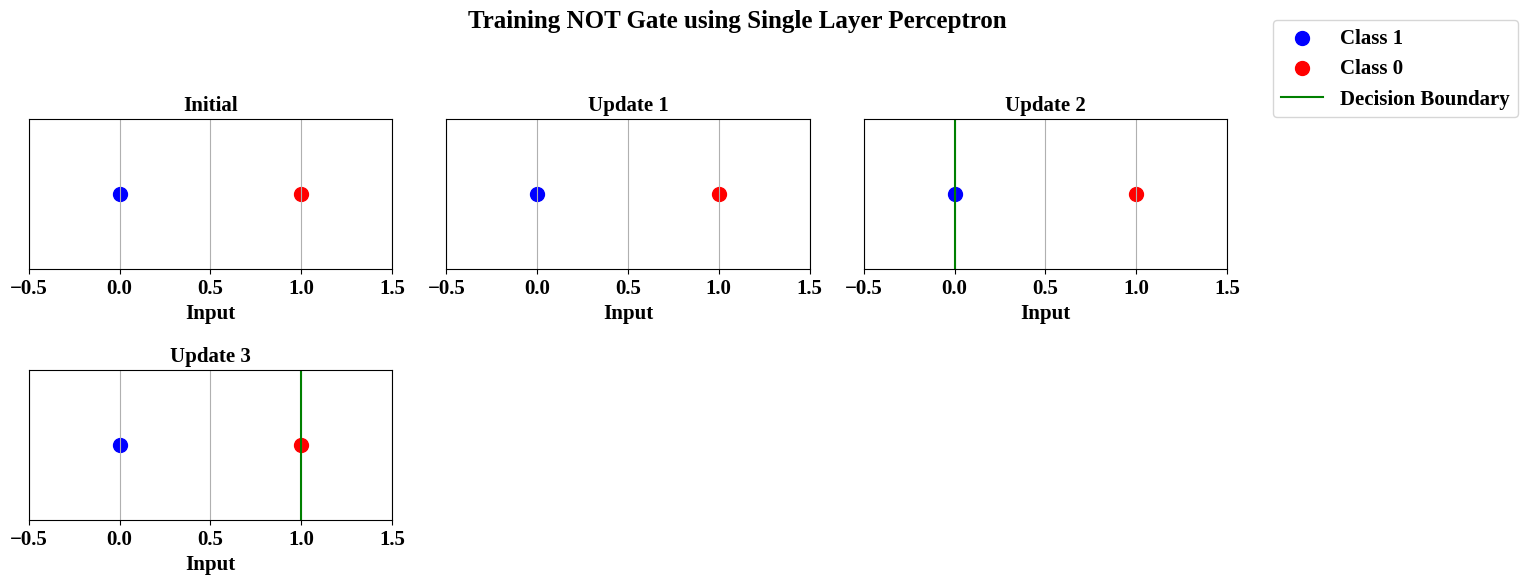

In [ ]:
# Training NOT gate
weight_not, bias_not = Perceptron_NOT(X_not, y_not)